In [1]:
print("Lohith V P -  24BAD064")
import numpy as np
import pandas as pd
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

Lohith V P -  24BAD064


In [23]:
df = pd.read_csv("u.data", sep="\t", names=["user", "item", "rating", "timestamp"])
df.head()

,user,item,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [24]:
user_item_matrix = df.pivot(index="user", columns="item", values="rating")
user_item_matrix.head()

item,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
user_item_filled = user_item_matrix.fillna(0)

In [26]:
nmf_model = NMF(n_components=20, init='random', random_state=42)
W = nmf_model.fit_transform(user_item_filled)
H = nmf_model.components_

c:\Users\karth\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [27]:
reconstructed_matrix = np.dot(W, H)

reconstructed_df = pd.DataFrame(
    reconstructed_matrix,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)
reconstructed_df.head()

item,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user,,,,,,,,,,,,,,,,,,,,,
1,4.255518,2.088239,1.426406,3.039424,0.966848,0.479364,4.975706,2.295917,3.171577,2.066155,...,0.011053,0.032096,0.021676,0.014451,0.012538,0.001367,0.004102,0.002735,0.033152,0.057808
2,2.260129,0.007158,0.014160,0.282828,0.084701,0.402371,1.472045,0.521715,3.096140,0.772625,...,0.001946,0.000000,0.011960,0.007974,0.000902,0.008961,0.026882,0.017921,0.000000,0.000000
3,0.198077,0.001735,0.042879,0.089242,0.002221,0.060573,0.144149,0.086057,0.161456,0.023714,...,0.002372,0.000110,0.006510,0.004340,0.001057,0.007683,0.023050,0.015367,0.000564,0.000316
4,0.651835,0.001968,0.004466,0.055929,0.060715,0.033048,0.317296,0.083672,0.085711,0.009112,...,0.000202,0.000740,0.000961,0.000641,0.001942,0.003810,0.011429,0.007619,0.000096,0.000000
5,3.323195,1.277656,0.296457,1.468815,0.729498,0.000000,3.206666,1.149873,0.071506,0.519362,...,0.000000,0.000473,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000735,0.003839


In [28]:
# Convert to arrays
actual = user_item_matrix.values
predicted = reconstructed_df.values

# Mask (only where original ratings exist)
mask = ~np.isnan(actual)

# Filter values
actual_filtered = actual[mask]
predicted_filtered = predicted[mask]

# RMSE
rmse = np.sqrt(mean_squared_error(actual_filtered, predicted_filtered))



print("RMSE:", rmse)


RMSE: 2.227159257114767


In [29]:
def recommend(user_id, n=5):
    user_ratings = reconstructed_df.loc[user_id]
    already_rated = user_item_matrix.loc[user_id].dropna().index
    
    recommendations = user_ratings.drop(already_rated)
    return recommendations.sort_values(ascending=False).head(n)

recommend(1, 5)

item
408    3.840898
275    3.582340
433    3.514486
655    3.456334
318    3.259907
Name: 1, dtype: float64

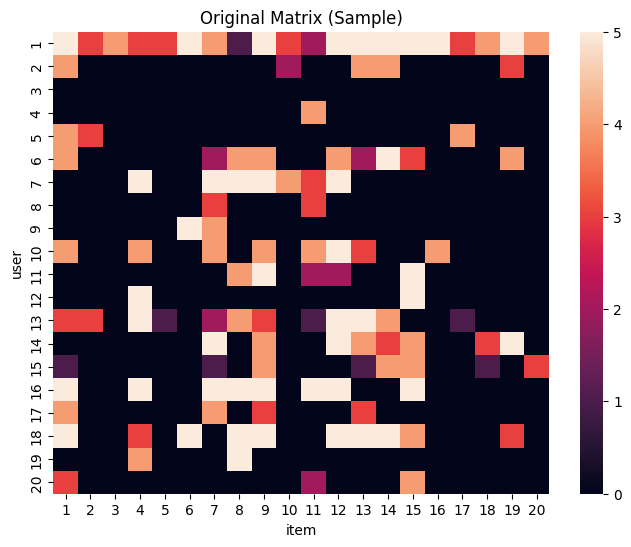

In [30]:
plt.figure(figsize=(8,6))
sns.heatmap(user_item_filled.iloc[:20, :20])
plt.title("Original Matrix (Sample)")
plt.show()

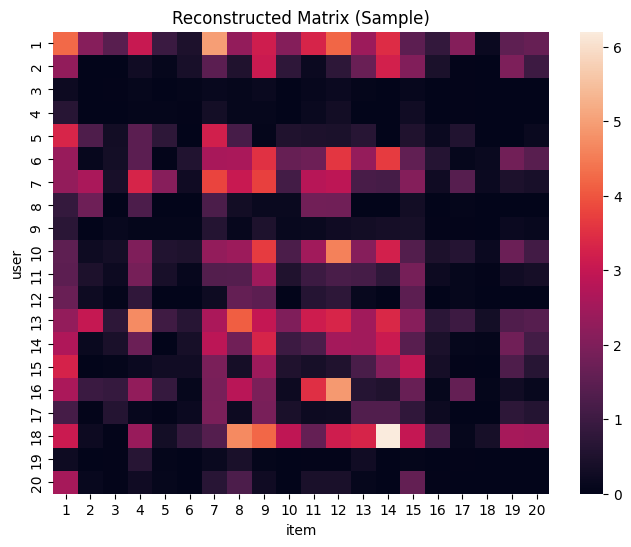

In [31]:
plt.figure(figsize=(8,6))
sns.heatmap(reconstructed_df.iloc[:20, :20])
plt.title("Reconstructed Matrix (Sample)")
plt.show()